In [1]:
import sys
import os
os.getcwd()
sys.path.insert(0, r"F:\trip_duration_project")
from features.main import run_changes
from features.features_extraction import calculate_airport_distance
from utils.data_helper import save_processed_data
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\pc\Desktop\Trip duration dataset\split\raw\train.csv")
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1,id3485529,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827
2,id1816614,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614
3,id1050851,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867
4,id0140657,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967


In [3]:
df = run_changes(df)
df.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,month,is_weekend,is_rush_hour,haversine_distance_km,manhattan_distance_km,bearing,speed_kmh
0,2,1,-73.985611,40.735943,-73.980331,40.760468,N,1040,7,2,6,0,1,2.763050,3.166208,9.261031,9.564402
1,2,1,-73.978394,40.764351,-73.991623,40.749859,N,827,12,6,4,1,0,1.959178,2.720951,214.667627,8.528467
2,2,5,-73.989059,40.744389,-73.973381,40.748692,N,614,2,6,6,1,0,1.404772,1.796092,70.081271,8.236447
3,2,2,-73.990326,40.731136,-73.991264,40.748917,N,867,17,3,5,0,1,1.978660,2.052537,357.710323,8.215888
4,1,4,-73.789497,40.646675,-73.987137,40.759232,N,4967,17,3,5,0,1,20.837745,29.124966,306.979191,15.102855


In [4]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,hour,day_of_week,month,is_weekend,is_rush_hour,haversine_distance_km,manhattan_distance_km,bearing,speed_kmh
count,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,9.992880e+05,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000
mean,1.534798,1.665471,-73.973520,40.750981,-73.973509,40.751820,9.538297e+02,13.604371,3.051653,3.515209,0.285804,0.306704,3.419516,4.411973,153.585592,14.390250
std,0.498788,1.315874,0.037991,0.028016,0.035043,0.032079,3.881017e+03,6.399911,1.954626,1.681115,0.451797,0.461126,3.881419,5.154562,104.267567,12.582310
min,1.000000,0.000000,-74.233780,40.506294,-74.248909,40.508598,1.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,-73.991859,40.737389,-73.991341,40.735939,3.970000e+02,9.000000,1.000000,2.000000,0.000000,0.000000,1.232009,1.568063,44.384219,9.118406
50%,2.000000,1.000000,-73.981735,40.754135,-73.979774,40.754551,6.610000e+02,14.000000,3.000000,4.000000,0.000000,0.000000,2.090391,2.680223,168.834325,12.784603
75%,2.000000,2.000000,-73.967377,40.768379,-73.963074,40.769821,1.074000e+03,19.000000,5.000000,5.000000,1.000000,1.000000,3.866845,4.979899,224.559787,17.831674
max,2.000000,7.000000,-73.703575,40.991917,-73.700302,40.996105,2.227612e+06,23.000000,6.000000,6.000000,1.000000,1.000000,47.765129,67.420209,359.989139,9274.836731


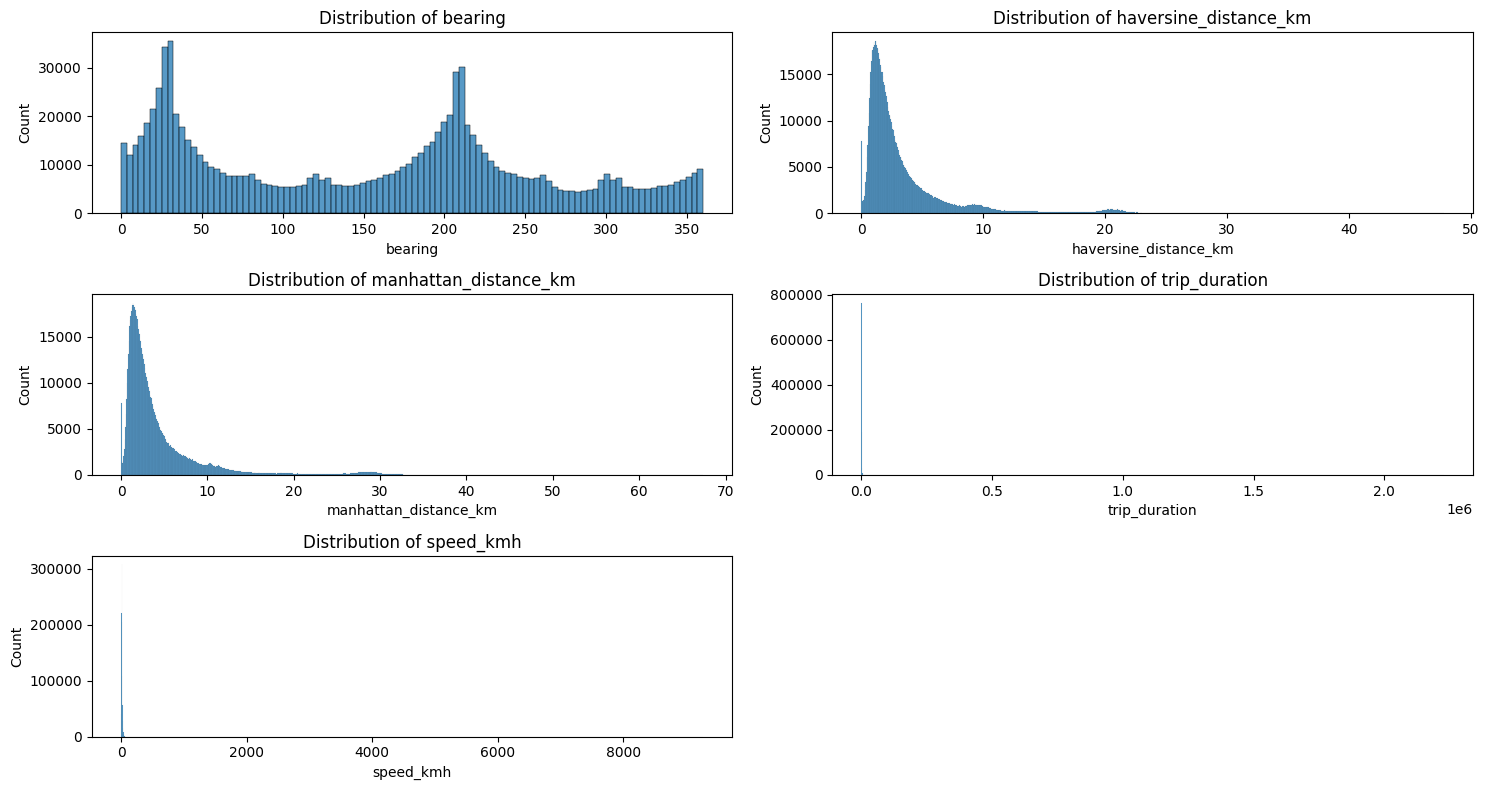

In [5]:
distance_target_features = ["bearing" , "haversine_distance_km" , "manhattan_distance_km" , "trip_duration" , "speed_kmh"]
plt.figure(figsize = (15 , 8))
for i , col in enumerate(distance_target_features):
    plt.subplot(3 , 2 , i + 1)
    sns.histplot(data = df , x = col)
    plt.title(f"Distribution of {col}") 
plt.tight_layout()
plt.show()

the haversine_distance_km and manhattan_distance_km are right skewed

Now we want to handle outliers 

In [6]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,hour,day_of_week,month,is_weekend,is_rush_hour,haversine_distance_km,manhattan_distance_km,bearing,speed_kmh
count,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,9.992880e+05,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000
mean,1.534798,1.665471,-73.973520,40.750981,-73.973509,40.751820,9.538297e+02,13.604371,3.051653,3.515209,0.285804,0.306704,3.419516,4.411973,153.585592,14.390250
std,0.498788,1.315874,0.037991,0.028016,0.035043,0.032079,3.881017e+03,6.399911,1.954626,1.681115,0.451797,0.461126,3.881419,5.154562,104.267567,12.582310
min,1.000000,0.000000,-74.233780,40.506294,-74.248909,40.508598,1.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,-73.991859,40.737389,-73.991341,40.735939,3.970000e+02,9.000000,1.000000,2.000000,0.000000,0.000000,1.232009,1.568063,44.384219,9.118406
50%,2.000000,1.000000,-73.981735,40.754135,-73.979774,40.754551,6.610000e+02,14.000000,3.000000,4.000000,0.000000,0.000000,2.090391,2.680223,168.834325,12.784603
75%,2.000000,2.000000,-73.967377,40.768379,-73.963074,40.769821,1.074000e+03,19.000000,5.000000,5.000000,1.000000,1.000000,3.866845,4.979899,224.559787,17.831674
max,2.000000,7.000000,-73.703575,40.991917,-73.700302,40.996105,2.227612e+06,23.000000,6.000000,6.000000,1.000000,1.000000,47.765129,67.420209,359.989139,9274.836731


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999288 entries, 0 to 999999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   vendor_id              999288 non-null  int64  
 1   passenger_count        999288 non-null  int64  
 2   pickup_longitude       999288 non-null  float64
 3   pickup_latitude        999288 non-null  float64
 4   dropoff_longitude      999288 non-null  float64
 5   dropoff_latitude       999288 non-null  float64
 6   store_and_fwd_flag     999288 non-null  object 
 7   trip_duration          999288 non-null  int64  
 8   hour                   999288 non-null  int32  
 9   day_of_week            999288 non-null  int32  
 10  month                  999288 non-null  int32  
 11  is_weekend             999288 non-null  int64  
 12  is_rush_hour           999288 non-null  int64  
 13  haversine_distance_km  999288 non-null  float64
 14  manhattan_distance_km  999288 non-null  f

In [8]:
df.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,month,is_weekend,is_rush_hour,haversine_distance_km,manhattan_distance_km,bearing,speed_kmh
0,2,1,-73.985611,40.735943,-73.980331,40.760468,N,1040,7,2,6,0,1,2.763050,3.166208,9.261031,9.564402
1,2,1,-73.978394,40.764351,-73.991623,40.749859,N,827,12,6,4,1,0,1.959178,2.720951,214.667627,8.528467
2,2,5,-73.989059,40.744389,-73.973381,40.748692,N,614,2,6,6,1,0,1.404772,1.796092,70.081271,8.236447
3,2,2,-73.990326,40.731136,-73.991264,40.748917,N,867,17,3,5,0,1,1.978660,2.052537,357.710323,8.215888
4,1,4,-73.789497,40.646675,-73.987137,40.759232,N,4967,17,3,5,0,1,20.837745,29.124966,306.979191,15.102855


In [9]:
airports = {
    "jfk": (40.6413, -73.7781),
    "lga": (40.7769, -73.8740)
}

locations = {
    "pickup": ("pickup_latitude", "pickup_longitude"),
    "dropoff": ("dropoff_latitude", "dropoff_longitude")
}

for airport, (airport_lat, airport_lon) in airports.items():
    for loc, (lat_col, lon_col) in locations.items():
        new_col = f"{airport}_{loc}_dist"
        df = calculate_airport_distance(df , lat_col , lon_col , airport_lat , airport_lon , new_col)

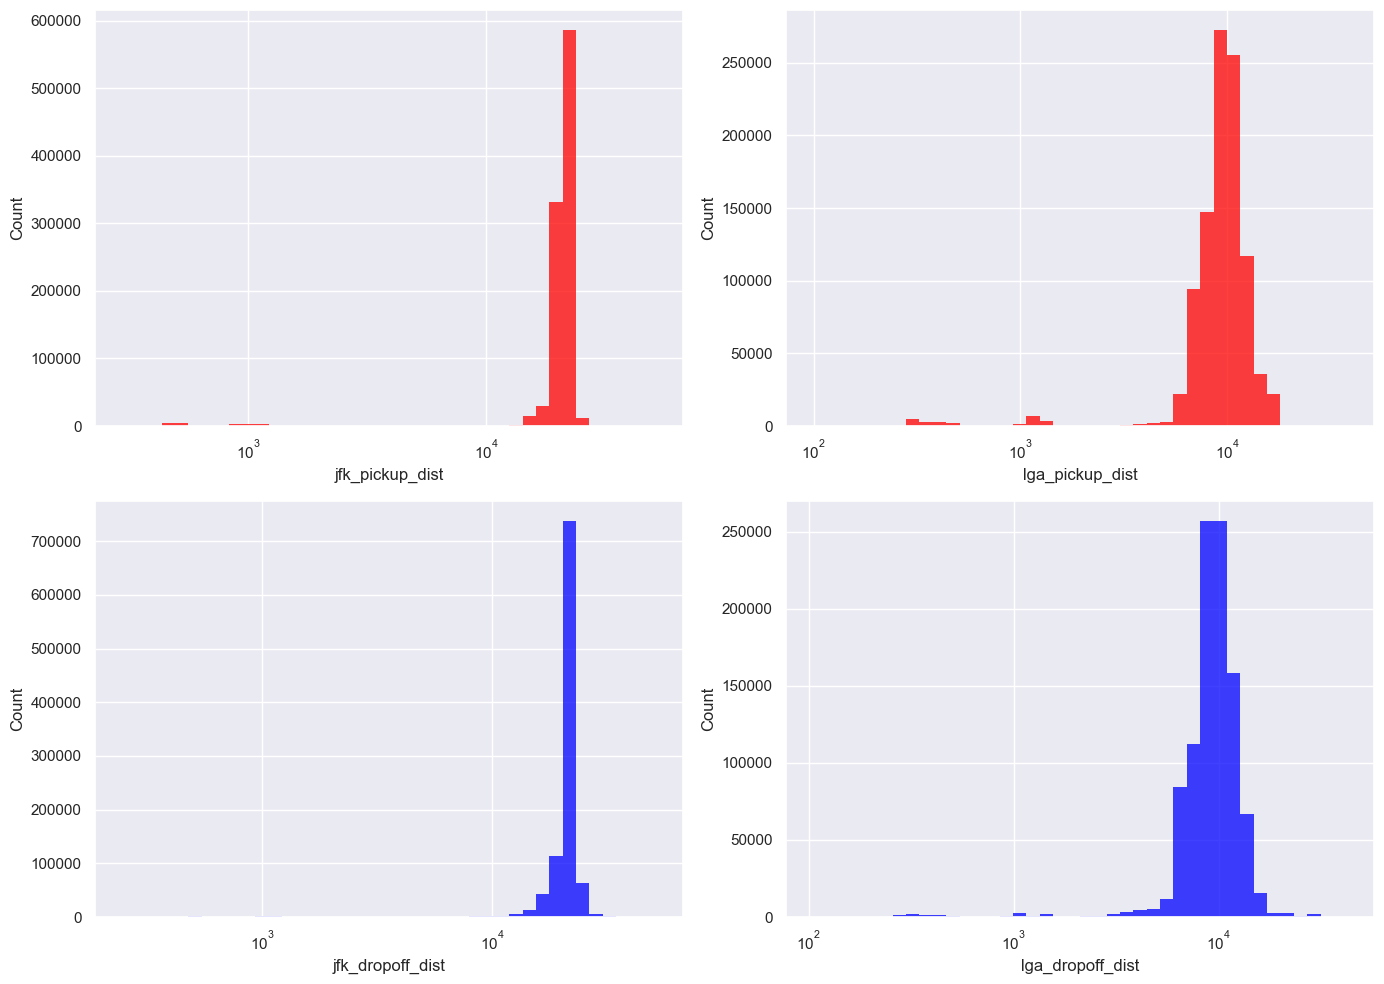

In [10]:
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(data=df, x='jfk_pickup_dist', color='red', log_scale = True , bins=40 , ax=axes[0, 0] , edgecolor="none")
sns.histplot(data=df, x='lga_pickup_dist', color='red', bins=40 , log_scale = True , ax=axes[0, 1], edgecolor="none")
sns.histplot(data=df, x='jfk_dropoff_dist', color='blue', bins=40, log_scale = True , ax=axes[1, 0], edgecolor="none")
sns.histplot(data=df, x='lga_dropoff_dist', color='blue', bins=40, log_scale = True  , ax=axes[1, 1], edgecolor="none")

plt.tight_layout()
plt.show()

here we can see that some trips have less than 2 km trips so they are possibly from one airport to another

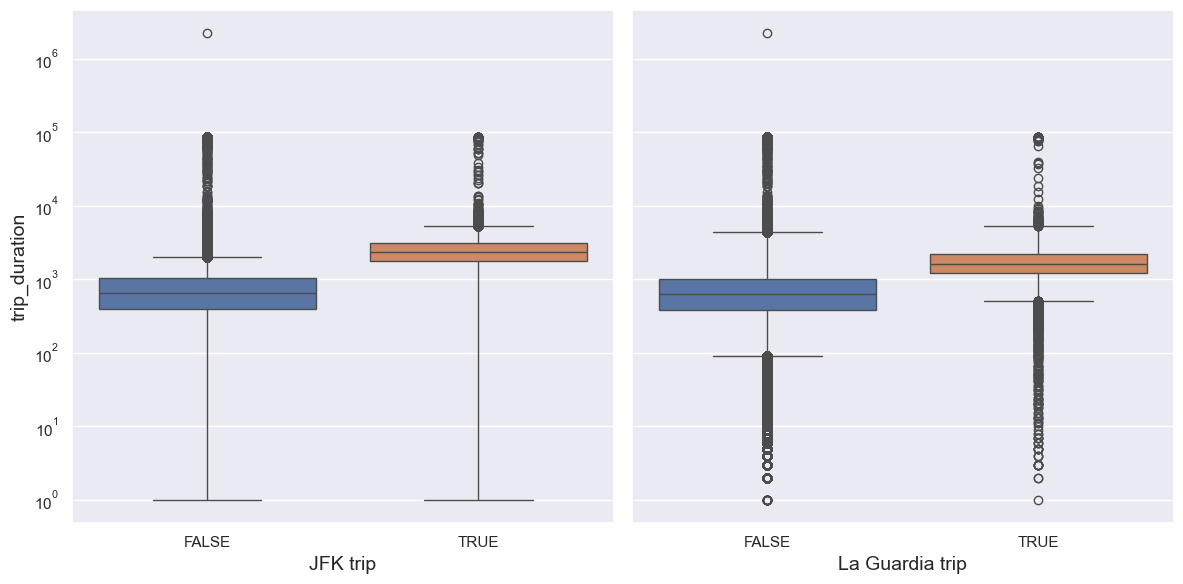

In [11]:
df['jfk_trip'] = (df['jfk_pickup_dist'] <= 2000) | (df['jfk_dropoff_dist'] <= 2000)
df['lga_trip'] = (df['lga_pickup_dist'] <= 2000) | (df['lga_dropoff_dist'] <= 2000)

# 2. Set up the 1x2 layout
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

sns.boxplot(
    data=df, 
    x='jfk_trip', 
    y='trip_duration', 
    hue='jfk_trip', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_yscale("log")
axes[0].set_xlabel("JFK trip", fontsize=14)
axes[0].set_ylabel("trip_duration", fontsize=14)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["FALSE", "TRUE"])

sns.boxplot(
    data=df, 
    x='lga_trip', 
    y='trip_duration', 
    hue='lga_trip', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_yscale("log")
axes[1].set_xlabel("La Guardia trip", fontsize=14)
axes[1].set_ylabel("trip_duration", fontsize=14)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["FALSE", "TRUE"])

# Adjust spacing and display
plt.tight_layout()
plt.show()

Since airports are not in the center of the city they usually take higher average trip durations

In [12]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,hour,day_of_week,month,is_weekend,is_rush_hour,haversine_distance_km,manhattan_distance_km,bearing,speed_kmh,jfk_pickup_dist,jfk_dropoff_dist,lga_pickup_dist,lga_dropoff_dist
count,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,9.992880e+05,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000,999288.000000
mean,1.534798,1.665471,-73.973520,40.750981,-73.973509,40.751820,9.538297e+02,13.604371,3.051653,3.515209,0.285804,0.306704,3.419516,4.411973,153.585592,14.390250,20714.464409,20870.724487,9589.416818,9613.729599
std,0.498788,1.315874,0.037991,0.028016,0.035043,0.032079,3.881017e+03,6.399911,1.954626,1.681115,0.451797,0.461126,3.881419,5.154562,104.267567,12.582310,3323.057115,2879.684270,2558.653424,2651.157689
min,1.000000,0.000000,-74.233780,40.506294,-74.248909,40.508598,1.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,295.031104,244.474957,98.937744,104.388487
25%,1.000000,1.000000,-73.991859,40.737389,-73.991341,40.735939,3.970000e+02,9.000000,1.000000,2.000000,0.000000,0.000000,1.232009,1.568063,44.384219,9.118406,20580.762489,20520.755696,8345.424897,8221.925263
50%,2.000000,1.000000,-73.981735,40.754135,-73.979774,40.754551,6.610000e+02,14.000000,3.000000,4.000000,0.000000,0.000000,2.090391,2.680223,168.834325,12.784603,21206.593257,21200.302274,9580.282509,9471.560203
75%,2.000000,2.000000,-73.967377,40.768379,-73.963074,40.769821,1.074000e+03,19.000000,5.000000,5.000000,1.000000,1.000000,3.866845,4.979899,224.559787,17.831674,21888.900649,21937.240961,10978.981540,10955.297539
max,2.000000,7.000000,-73.703575,40.991917,-73.700302,40.996105,2.227612e+06,23.000000,6.000000,6.000000,1.000000,1.000000,47.765129,67.420209,359.989139,9274.836731,51788.352638,51788.819708,38079.876226,42389.423063


In [13]:
df.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,...,haversine_distance_km,manhattan_distance_km,bearing,speed_kmh,jfk_pickup_dist,jfk_dropoff_dist,lga_pickup_dist,lga_dropoff_dist,jfk_trip,lga_trip
0,2,1,-73.985611,40.735943,-73.980331,40.760468,N,1040,7,2,...,2.763050,3.166208,9.261031,9.564402,20417.413747,21592.104133,10445.957615,9139.085320,False,False
1,2,1,-73.978394,40.764351,-73.991623,40.749859,N,827,12,6,...,1.959178,2.720951,214.667627,8.528467,21732.215325,21673.969367,8901.166571,10352.531650,False,False
2,2,5,-73.989059,40.744389,-73.973381,40.748692,N,614,2,6,...,1.404772,1.796092,70.081271,8.236447,21159.816928,20338.277012,10343.098992,8938.409560,False,False
3,2,2,-73.990326,40.731136,-73.991264,40.748917,N,867,17,3,...,1.978660,2.052537,357.710323,8.215888,20493.889610,21590.729540,11040.985335,10354.704619,False,False
4,1,4,-73.789497,40.646675,-73.987137,40.759232,N,4967,17,3,...,20.837745,29.124966,306.979191,15.102855,1132.223016,21965.682432,16137.178131,9728.208341,True,False


<Axes: xlabel='trip_duration', ylabel='manhattan_distance_km'>

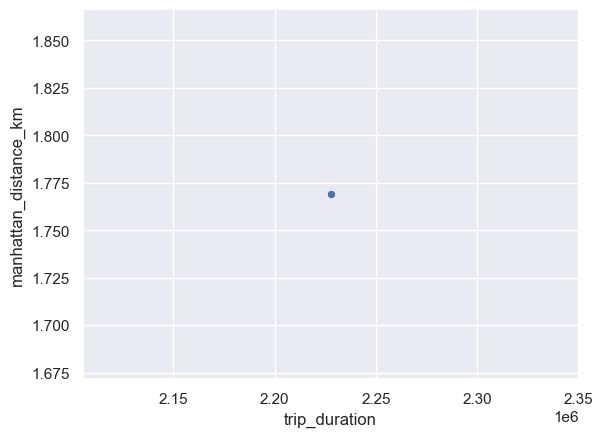

In [14]:
greater_than_24 = df[df["trip_duration"] >= 24 * 60 * 60]
sns.scatterplot(data=greater_than_24, x="trip_duration", y="manhattan_distance_km")

(999287, 23)

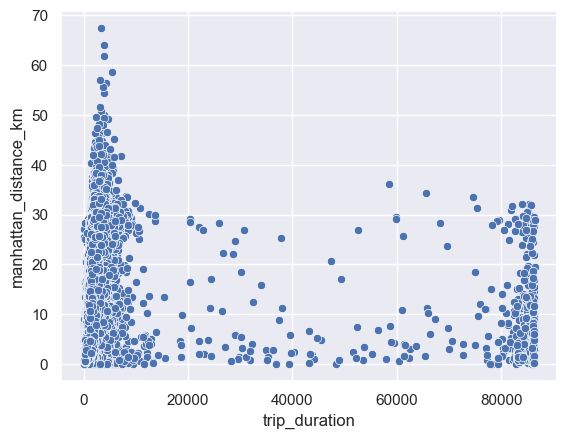

In [15]:
less_than_24 = df[df["trip_duration"] < 24 * 60 * 60]
sns.scatterplot(data=less_than_24, x="trip_duration", y="manhattan_distance_km")
less_than_24.shape

Here we can observe two things:

1- 80000 seconds for 10km is too much 

2- there are some trips with 0 distance (outliers)

In [16]:
# Convert 22 hours to seconds
max_duration = 22 * 3600

# Apply the filters
df = df[
    (df['trip_duration'] < max_duration) & 
    ((df['manhattan_distance_km'] > 0) | ((df['manhattan_distance_km'] <= 0.01) & (df['trip_duration'] < 60))) & 
    (df['trip_duration'] > 10) & 
    (df['speed_kmh'] < 100)
]
df = df[df["passenger_count"] > 0]

In [17]:
df = df.drop(columns=["store_and_fwd_flag" , "speed_kmh"], errors="ignore")
df.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,hour,day_of_week,month,...,is_rush_hour,haversine_distance_km,manhattan_distance_km,bearing,jfk_pickup_dist,jfk_dropoff_dist,lga_pickup_dist,lga_dropoff_dist,jfk_trip,lga_trip
0,2,1,-73.985611,40.735943,-73.980331,40.760468,1040,7,2,6,...,1,2.763050,3.166208,9.261031,20417.413747,21592.104133,10445.957615,9139.085320,False,False
1,2,1,-73.978394,40.764351,-73.991623,40.749859,827,12,6,4,...,0,1.959178,2.720951,214.667627,21732.215325,21673.969367,8901.166571,10352.531650,False,False
2,2,5,-73.989059,40.744389,-73.973381,40.748692,614,2,6,6,...,0,1.404772,1.796092,70.081271,21159.816928,20338.277012,10343.098992,8938.409560,False,False
3,2,2,-73.990326,40.731136,-73.991264,40.748917,867,17,3,5,...,1,1.978660,2.052537,357.710323,20493.889610,21590.729540,11040.985335,10354.704619,False,False
4,1,4,-73.789497,40.646675,-73.987137,40.759232,4967,17,3,5,...,1,20.837745,29.124966,306.979191,1132.223016,21965.682432,16137.178131,9728.208341,True,False


store_and_fwd_flag is removed because it has no effect on trip duration

speed_kmh is removed because it cause data leakage

In [18]:
df["trip_duration"] = np.log1p(df["trip_duration"])
df["haversine_distance_km"] = np.log1p(df["haversine_distance_km"])
df["manhattan_distance_km"] = np.log1p(df["manhattan_distance_km"])

In [20]:
save_processed_data(df , r"C:\Users\pc\Desktop\Trip duration dataset\split\processed\train.csv")

 Processed data saved to C:\Users\pc\Desktop\Trip duration dataset\split\processed\train.csv
